In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genextreme
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc
from pygam import PoissonGAM, LinearGAM
from nba_api.stats.static import players, teams
from scipy.stats import gumbel_r
import os

In [34]:
# Pré-processamento dos dados
def preprocess_data(df):
    df.dropna(inplace=True)  # Remover valores nulos
    return df

players_list = players.get_players()
player_names = ["Damian Lillard", "Giannis Antetokounmpo", "Brook Lopez"]
player_ids = {
    player['full_name']: player['id']
    for player in players_list if player['full_name'] in player_names
}
paths_to_csvs = {
    'pt1' : {},
    'pt2' : {
        'rf1': "../Parte2/rf1.csv",
        'rf2': "../Parte2/rf2.csv",
        'rf3': "../Parte2/rf3.csv",
        'rf4': "../Parte2/rf4.csv",
        'rf5': "../Parte2/rf5.csv",
        'rf6': "../Parte2/rf6.csv",
        #'rf7': "../Parte2/rf7.csv",
        #'rf8': "../Parte2/rf8.csv",
        'rf9': "../Parte2/rf9.csv",
        'rf10': "../Parte2/rf10.csv",
    }
}
print(os.getcwd())
csv_data = {
    key: {subkey: pd.read_csv(path) for subkey, path in subdict.items()}
    for key, subdict in paths_to_csvs.items()
}

# Exibir as chaves para verificar a estrutura
print(csv_data.keys())
csv_data['pt2']['rf6']


D:\Users\netob\PycharmProjects\FCD_Projeto_Back\Parte 3
dict_keys(['pt1', 'pt2'])


,Player,Median_PTS,Median_REB,Median_AST,Below_Median_PTS,Below_Median_REB,Below_Median_AST
0,Giannis Antetokounmpo,32.0,12.0,6.0,48.78%,39.02%,48.78%
1,Damian Lillard,25.0,4.0,7.0,39.53%,25.58%,37.21%
2,Brook Lopez,12.5,5.0,1.0,50.00%,44.00%,22.00%


--- Análise para Giannis Antetokounmpo ---

Métrica: Median_PTS


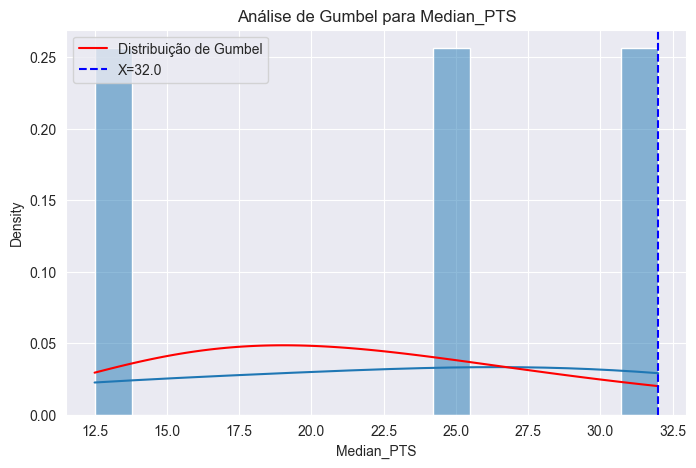

Probabilidade de X > 32.0: 0.1657
Probabilidade de X ≥ 32.0: 0.1657
Probabilidade de X < 32.0: 0.8343
Probabilidade de X ≤ 32.0: 0.8343

Métrica: Median_REB


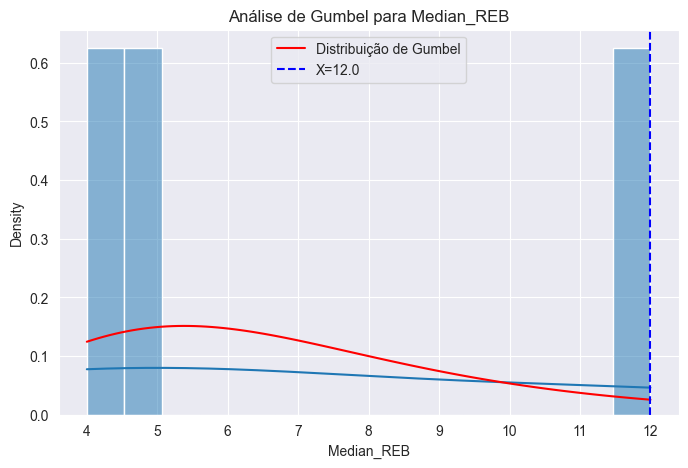

Probabilidade de X > 12.0: 0.0638
Probabilidade de X ≥ 12.0: 0.0638
Probabilidade de X < 12.0: 0.9362
Probabilidade de X ≤ 12.0: 0.9362

Métrica: Median_AST


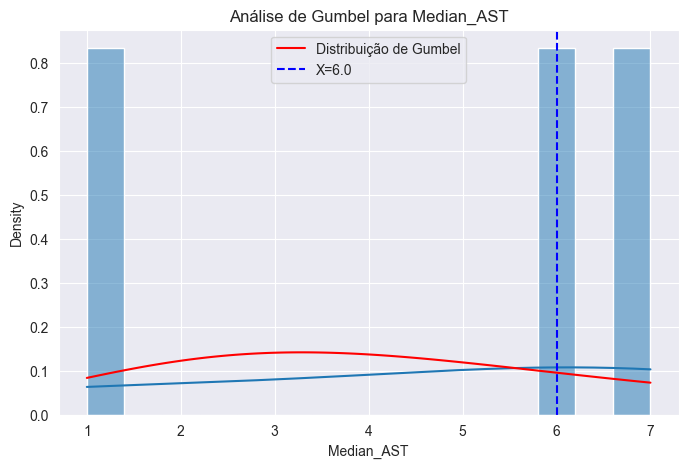

Probabilidade de X > 6.0: 0.2968
Probabilidade de X ≥ 6.0: 0.2968
Probabilidade de X < 6.0: 0.7032
Probabilidade de X ≤ 6.0: 0.7032
--- Análise para Damian Lillard ---

Métrica: Median_PTS


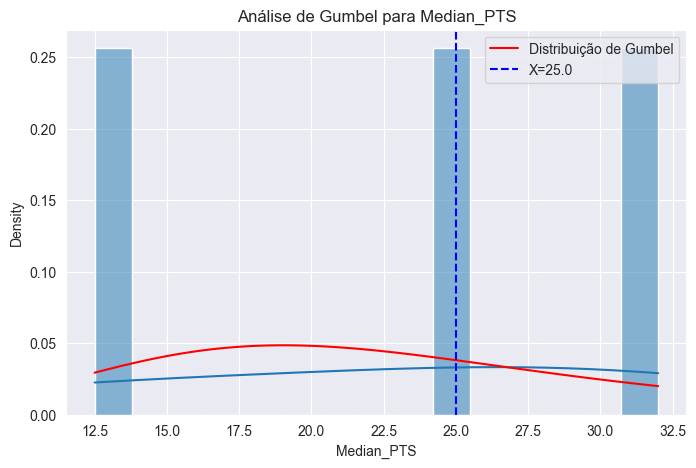

Probabilidade de X > 25.0: 0.3658
Probabilidade de X ≥ 25.0: 0.3658
Probabilidade de X < 25.0: 0.6342
Probabilidade de X ≤ 25.0: 0.6342

Métrica: Median_REB


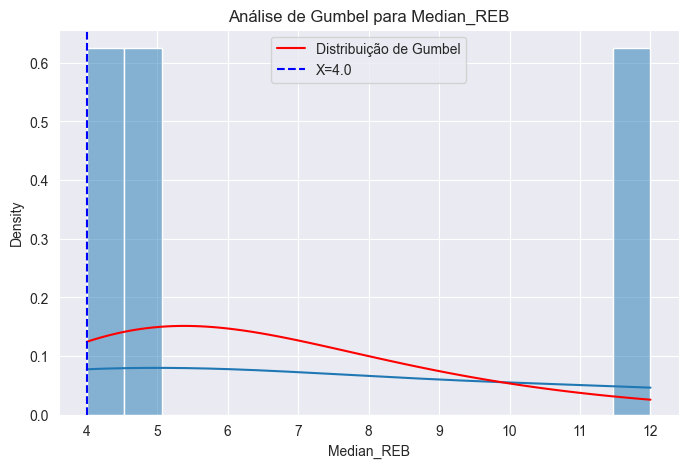

Probabilidade de X > 4.0: 0.8287
Probabilidade de X ≥ 4.0: 0.8287
Probabilidade de X < 4.0: 0.1713
Probabilidade de X ≤ 4.0: 0.1713

Métrica: Median_AST


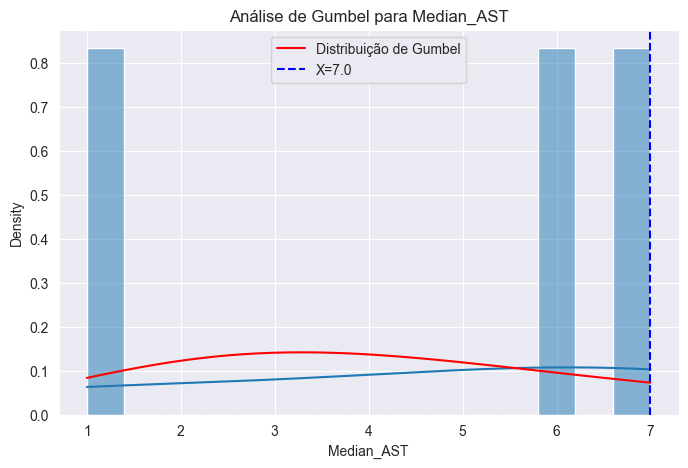

Probabilidade de X > 7.0: 0.2131
Probabilidade de X ≥ 7.0: 0.2131
Probabilidade de X < 7.0: 0.7869
Probabilidade de X ≤ 7.0: 0.7869
--- Análise para Brook Lopez ---

Métrica: Median_PTS


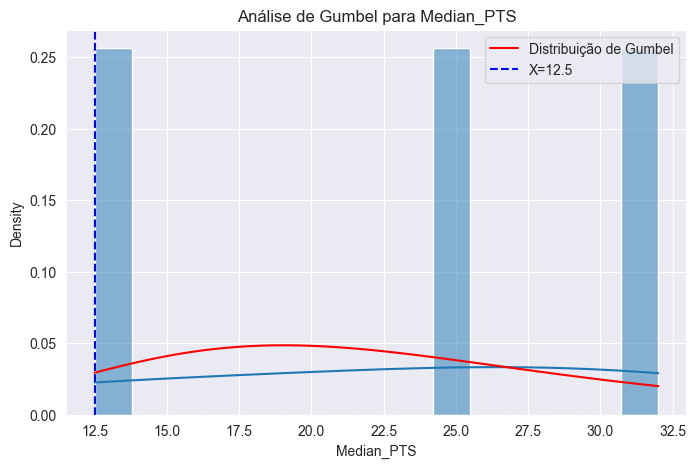

Probabilidade de X > 12.5: 0.9059
Probabilidade de X ≥ 12.5: 0.9059
Probabilidade de X < 12.5: 0.0941
Probabilidade de X ≤ 12.5: 0.0941

Métrica: Median_REB


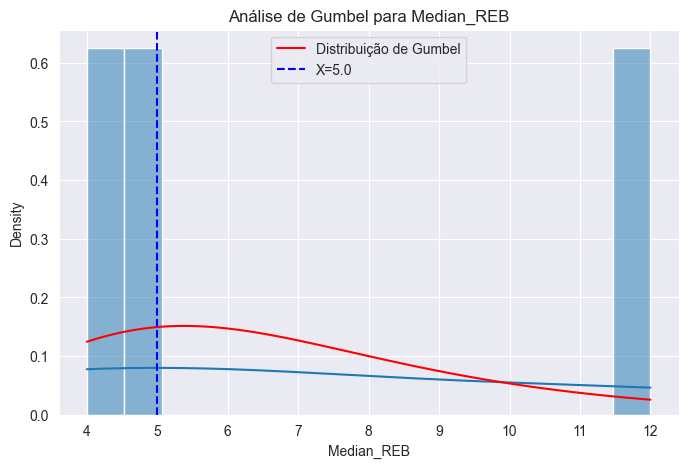

Probabilidade de X > 5.0: 0.6896
Probabilidade de X ≥ 5.0: 0.6896
Probabilidade de X < 5.0: 0.3104
Probabilidade de X ≤ 5.0: 0.3104

Métrica: Median_AST


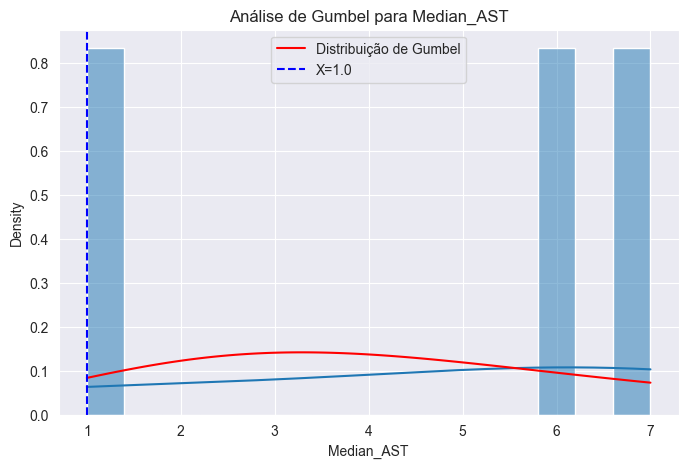

Probabilidade de X > 1.0: 0.9100
Probabilidade de X ≥ 1.0: 0.9100
Probabilidade de X < 1.0: 0.0900
Probabilidade de X ≤ 1.0: 0.0900


In [38]:
# RF1 - Modelagem de eventos extremos (Método de Gumbel)

# Carregar os dados
file_path = paths_to_csvs['pt2']['rf6']  # Substitua pelo caminho real
df = pd.read_csv(file_path)

def preprocess_data(df):
    df.dropna(inplace=True)  # Remover valores nulos
    return df

df = preprocess_data(df)

# Função para análise de Gumbel
def gumbel_analysis(df, column, x):
    params = gumbel_r.fit(df[column])  # Ajuste da distribuição
    x_values = np.linspace(df[column].min(), df[column].max(), 100)
    y_values = gumbel_r.pdf(x_values, *params)
    
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], kde=True, stat="density", bins=15)
    plt.plot(x_values, y_values, 'r-', label="Distribuição de Gumbel")
    plt.axvline(x, color='b', linestyle='--', label=f'X={x}')
    plt.legend()
    plt.title(f'Análise de Gumbel para {column}')
    plt.show()
    
    # Cálculo das probabilidades
    prob_greater = 1 - gumbel_r.cdf(x, *params)
    prob_greater_equal = gumbel_r.sf(x, *params)
    prob_less = gumbel_r.cdf(x, *params)
    prob_less_equal = prob_less  # CDF já inclui "menor ou igual"
    
    print(f'Probabilidade de X > {x}: {prob_greater:.4f}')
    print(f'Probabilidade de X ≥ {x}: {prob_greater_equal:.4f}')
    print(f'Probabilidade de X < {x}: {prob_less:.4f}')
    print(f'Probabilidade de X ≤ {x}: {prob_less_equal:.4f}')

# Aplicando para cada métrica e jogador
metrics = ["Median_PTS", "Median_REB", "Median_AST"]

for player in player_names:
    print(f'--- Análise para {player} ---')
    player_data = df[df["Player"] == player]
    for metric in metrics:
        x_value = player_data[metric].values[0]  # Pega a mediana como referência
        print(f'\nMétrica: {metric}')
        gumbel_analysis(df, metric, x_value)


In [7]:
# RF2 - Gráficos para visualização de extremos
def plot_gumbel_distribution(df, column):
    params = genextreme.fit(df[column])
    x = np.linspace(min(df[column]), max(df[column]), 100)
    y = genextreme.pdf(x, *params)

    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], kde=True, stat="density")
    plt.plot(x, y, 'r-', label="Distribuição de Gumbel")
    plt.legend()
    plt.title(f'Visualização de Gumbel para {column}')
    plt.show()


In [8]:
# RF3 - Regressão Linear
def linear_regression(df, independent_vars, dependent_var):
    X = df[independent_vars]
    y = df[dependent_var]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    plt.scatter(y_test, predictions)
    plt.xlabel("Valores Reais")
    plt.ylabel("Previsões")
    plt.title(f'Regressão Linear para {dependent_var}')
    plt.show()
    return model



In [9]:
# RF4 - Gráficos para regressão linear
def plot_regression_results(y_test, predictions):
    plt.scatter(y_test, predictions)
    plt.xlabel("Valores Reais")
    plt.ylabel("Previsões")
    plt.title("Gráfico de Regressão Linear")
    plt.show()


In [10]:
# RF5 - Regressão Logística
def logistic_regression(df, independent_vars, target):
    X = df[independent_vars]
    y = (df[target] > df[target].mean()).astype(int)  # Transformar em binário
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {target}')
    plt.show()
    return model



In [11]:
# RF6 - Gráficos para regressão logística
def plot_logistic_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Matriz de Confusão")
    plt.show()



In [12]:
# RF7 - Modelos GAMLSS usando PyGAM
def gamlss_poisson(df, independent_vars, target):
    X = df[independent_vars]
    y = df[target]
    model = PoissonGAM()
    model.fit(X, y)
    return model



In [13]:
# RF8 - Visualizações para GAMLSS
def plot_gamlss_results(model, X, y):
    plt.figure(figsize=(8, 5))
    plt.scatter(y, model.predict(X), alpha=0.5)
    plt.xlabel("Valores Reais")
    plt.ylabel("Previsões")
    plt.title("Resultados do Modelo GAMLSS")
    plt.show()


In [14]:
# Exemplo de uso
data = pd.read_csv('nba_data.csv')
data = preprocess_data(data)
gumbel_analysis(data, 'pontos')
plot_gumbel_distribution(data, 'pontos')
linear_model = linear_regression(data, ['tempo_quadra', 'arremessos_tentados', 'turnovers'], 'pontos')
logistic_model = logistic_regression(data, ['tempo_quadra', 'arremessos_tentados', 'turnovers'], 'pontos')
poisson_gam = gamlss_poisson(data, ['tempo_quadra', 'arremessos_tentados', 'turnovers'], 'pontos')


FileNotFoundError: [Errno 2] No such file or directory: 'nba_data.csv'